## Near field energy transfer calculation


### (1) Introduction
In this script, an example is provided for calculating the matrix element of photon absorption and photon emission from a point dipole source to a single particle orbital transition in a VO: MgO absorption center. In the following, I outline the basic mathematical framework, while the details can be found in Ref. [1].

The interaction Hamiltonian can be expressed as
$
\begin{equation}
H_{int} = \sum_{E = S, A} \sum_{i=1}^{N_E}\left[-\frac{e\hat{\textbf{p}}_i\cdot\hat{\textbf{A}}}{2m_0}-\frac{e\hat{\textbf{A}}\cdot\hat{\textbf{p}}_i}{2m_0}+e\hat{A}_0 +g\frac{e\hbar}{2m_0}\hat{\bf{\sigma}}_i\cdot\bar\nabla\times\hat{\textbf{A}}\right].
\end{equation}
$

The process of photon mediated energy transfer can be broken in photon emission from the source (S) to a specific multipolar mode ($\ket{1_{k,\alpha}}$), and then absorption of the photon into the absorption center (A). The matrix elements of these two processes are represented as $v_{k,\alpha}^{(S)}$ and $v_{k,\alpha}^{(A)}$. They can be expressed as the matrix element of the interaction Hamiltinian for the transitioin between the initial and final states of the source and absorber, i.e.,
$
\begin{equation}
v_{k,\alpha}^{(S)} = \langle \Phi_{GS}^{(S)} , 1_{k,\alpha s} \mid H_{\mathrm{int}} \mid \Phi_{ES}^{(S)} \rangle
\end{equation}
$
and 
$
\begin{equation}
v_{k,\alpha}^{(A)} = \langle \Phi_{ES}^{(A)} \mid H_{\mathrm{int}} \mid \Phi_{GS}^{(A)}, 1_{k,\alpha s} \rangle
\end{equation}
$

Then we compute the transition amplitude of the near field energy transfer under second order perturbation theory, resulting in the overall resonant energy transfer matrix element:
$
\begin{equation}
M = \frac{i \pi n_i}{\hbar c} \sum_{\alpha} v^{(S)}_{k_S,\alpha} v^{(A)}_{k_S,\alpha}.
\end{equation}
$

In this code, we go through computation of the near field resonant energy transfer matrix element, $M$ for the simple case when\
\(1) The source is an ideal point electric dipole.
\(2) The absorber contains a single electron transition between the s orbital and p orbital of a VO: MgO


### (2) Outline
This notebook assumes that the wavefunctions corresponding to the relevant single particle orbitals (here s and pz orbital of the F center in MgO) has been imported as the jsonized wavefunction objects. For details, see Notebook#1. The overall outline is as follows:

\(1) We define the emitters by creating an object of the Emitters_data class.

\(2) We define the relative positions as an object of the Positions_data class.

\(3) We compute the emission matrix element.

\(4) We compute the absorption matrix element.

\(5) We combine to get the matrix element of the resoannt energy transfer process.


### (1) Define Emitters

In [5]:
import sys, os

from pyRET import *
consts = Consts()

#%% Define emitters
Em_data = Emitters_data()

#Source point dipole
em = "A"
Em_data.EmType[em] = em
Em_data.nIndex[em] = nIndex = 2.0
Em_data.T1[em] = {}
Em_data.w[em] = {}
Em_data.k[em] = {}
Em_data.pMPs[em] = {}
transitions = ["EDz"]
for tran in transitions:
    
    Em_data.T1[em][tran] = 1e-6 #1us radiative lifetime
    Em_data.w[em][tran] = 5.0*consts.qe/consts.hbar - 1j/Em_data.T1[em][tran]

    Em_data.k[em][tran] = nIndex*Em_data.w[em][tran]/consts.c

    pEDA =  getED(Em_data.T1[em][tran], np.real(Em_data.w[em][tran]),nIndex)
    mMDA =  getMD(Em_data.T1[em][tran], np.real(Em_data.w[em][tran]),nIndex)    
    
    
    nx = np.array([1, 0, 0], dtype = complex)
    ny = np.array([0, 1, 0], dtype = complex)
    nz = np.array([0, 0, 1], dtype = complex)

    
    Em_data.pMPs[em][tran] = {}
    Em_data.pMPs[em][tran][1] = {}
    
    Parity = -1 if "ED" in tran else 1 #True for only dipole like modes
    Pval = pEDA if "ED" in tran else mMDA
    if "x" in tran: n = nx
    if "y" in tran: n = ny
    if "z" in tran: n = nz
    
    
    Em_data.pMPs[em][tran][1][Parity] = Pval*n
    



#Absorber: Oxygen vacancy in MgO:
em = "B"
stateis = ["VOs",]
statefs = ["VOpz",]
Em_data.EmType[em] = em
Em_data.T1[em] = {}
Em_data.w[em] = {}
Em_data.k[em] = {}
Em_data.pMPs[em] = {}
Em_data.nIndex[em] = nIndex = 2.4

#set the transitions energies
#etc.etc..

for statei in stateis:
    for statef in statefs:
        
        tran = f"{statei}-to-{statef}"
        Em_data.pMPs[em][tran] = {}

        Em_data.T1[em][tran] = -1
        Em_data.w[em][tran] = 0*consts.qe/consts.hbar

        Em_data.k[em][tran] = 0;#nIndex*Em_data.w[em][tran]/consts.c
        Em_data.pMPs[em][tran] = {}



### (2) Define Relative Positions

In [3]:
#% Define Position Data
phival = 0
thetaval = np.pi/2

Pos_data = Positions_data()

#Positions
RABs = 10**np.linspace(-9, -6, 5) 
TABs = np.array([thetaval]) 
PABs = np.array([phival])

RABg, TABg, PABg = np.meshgrid(RABs, TABs, PABs)
RABvects = pol2cart(RABg, TABg, PABg, np.zeros(3))

#Define and save Posiotions data class:

Pos_data.Rs["A"] = {}
Pos_data.Rs["A"]["B"] = RABs
Pos_data.Ps["A"] = {}
Pos_data.Ps["A"]["B"] = PABs
Pos_data.Ts["A"] = {}
Pos_data.Ts["A"]["B"] = TABs
Pos_data.Rg["A"] = {}
Pos_data.Rg["A"]["B"] = RABg
Pos_data.Pg["A"] = {}
Pos_data.Pg["A"]["B"] = PABg
Pos_data.Tg["A"] = {}
Pos_data.Tg["A"]["B"] = TABg
Pos_data.Rvects["A"] = {}
Pos_data.Rvects["A"]["B"] = RABvects


### (3) & (4). Compute emission and absorption matrix elements

In [7]:
#Define transitions at the source and absorber
source_id = "A"
absorber_id = "B"
source_transition = "EDz"
absorber_transition = "VOs-to-VOpz"

#Photon energy same as the source transition energy
omega = Em_data.w[source_id][source_transition]

#Curate the wavefunctions from previously extracted data
cwd = os.getcwd()
parent = os.path.dirname(cwd)
wfdata = []
for state in ["VOs", "VOpz"]:
    _path = os.path.join(parent, "load_wavefunctions", "Extracted_Wavefunctions","VO_MgO", f"{state}.json")
    with open(_path, "r") as f:
        wfdata.append(WFunctions_data().Decode(json.load(f)))



#Compute source matrix elements
vS = computeV(
    absorber_id = source_id,
    emitter_id = source_id,
    absorber_transitions = ["EDz"],
    ws = np.ones(1)*omega,
    Lmax = 2,
    Em_data = Em_data,
    Pos_data = Pos_data,
    WF_data = None,
    parallel = False,
    )


#Compute absorption matrix elements
vA = computeV(
    absorber_id = absorber_id,
    emitter_id = source_id,
    absorber_transitions = ["VOs-to-VOpz"],
    ws = np.ones(1)*omega,
    Lmax = 2,
    Em_data = Em_data,
    Pos_data = Pos_data,
    WF_data = wfdata,
    parallel = False,
    )




### (5) Compute $M$, the resonant energy transfer matrix elements by combining the $v_S$ and $v_A$

Source matrix elements:
Shape of vS for L=1, M=0, P=-1 = (2, 2, 1)
Absorption matrix elements:
Shape of vA for L=1, M=0, P=-1 = (2, 2, 1, 1, 5, 1)


Text(0, 0.5, '|M_NRET|')

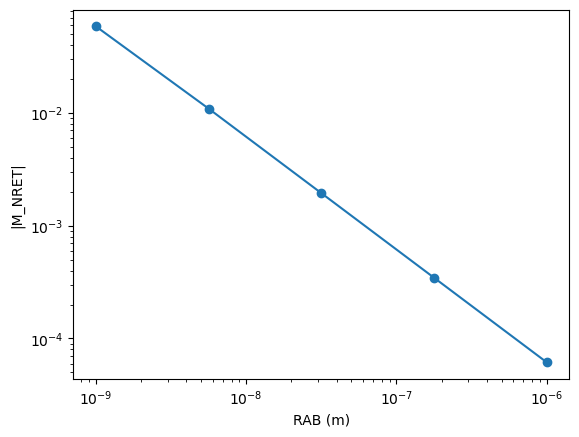

In [8]:
#The matrix element are stored as nested dictionaries with the following convention
#vS.V[emitter_id][absorber_id][transition][L][M][P] = numpy array of shape (2,2,...)
#L, M, P are the multipole orders.

#Let us look into the shape of the matrix elements computed
source_id = "A"
absorber_id = "B"
spin_flip_source = False
spin_flip_absorber = False
ispin_flip_source = 1 if spin_flip_source else 0
ispin_flip_absorber = 1 if spin_flip_absorber else 0
nIndex = 2.0

L, M, P = 1, 0, -1 #EDz mode

print("Source matrix elements:")
print(f"Shape of vS for L={L}, M={M}, P={P} = {vS.V[source_id][source_id][source_transition][L][M][P].shape}")
print("Absorption matrix elements:")
print(f"Shape of vA for L={L}, M={M}, P={P} = {vA.V[absorber_id][source_id][absorber_transition][L][M][P].shape}")


M_NRET_sph = np.zeros_like(RABs, dtype = complex)
#Summing over all multipoles (L, M, P)
for L in [1,2]:
    for M in range(-L, L+1):
        for P in [-1, 1]:
            vS_LMP = vS.V[source_id][source_id][source_transition][L][M][P][ispin_flip_source, ispin_flip_source,0]
            vA_LMP = vA.V[absorber_id][source_id][absorber_transition][L][M][P][ispin_flip_absorber, ispin_flip_absorber,0,0,:,0]
            
            M_NRET_sph += -1j*(nIndex * np.pi) /(consts.hbar * consts.c) * vS_LMP * vA_LMP

f, ax = plt.subplots()
ax.plot(RABs, np.abs(M_NRET_sph)/consts.hplank /1e9, marker = "o")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("RAB (m)")
ax.set_ylabel("|M_NRET|")

### References
[1] Chattaraj, Swarnabha, Supratik Guha, and Giulia Galli. “First-Principles Investigation of near-Field Energy Transfer between Localized Quantum Emitters in Solids.” Physical Review Research 6, no. 3 (2024): 033170. https://doi.org/10.1103/PhysRevResearch.6.033170.
[2] Chattaraj, Swarnabha, and Giulia Galli. “Energy Transfer between Localized Emitters in Photonic Cavities from First Principles.” Physical Review Research 7, no. 3 (2025): 033229. https://doi.org/10.1103/8h8j-b79r.
